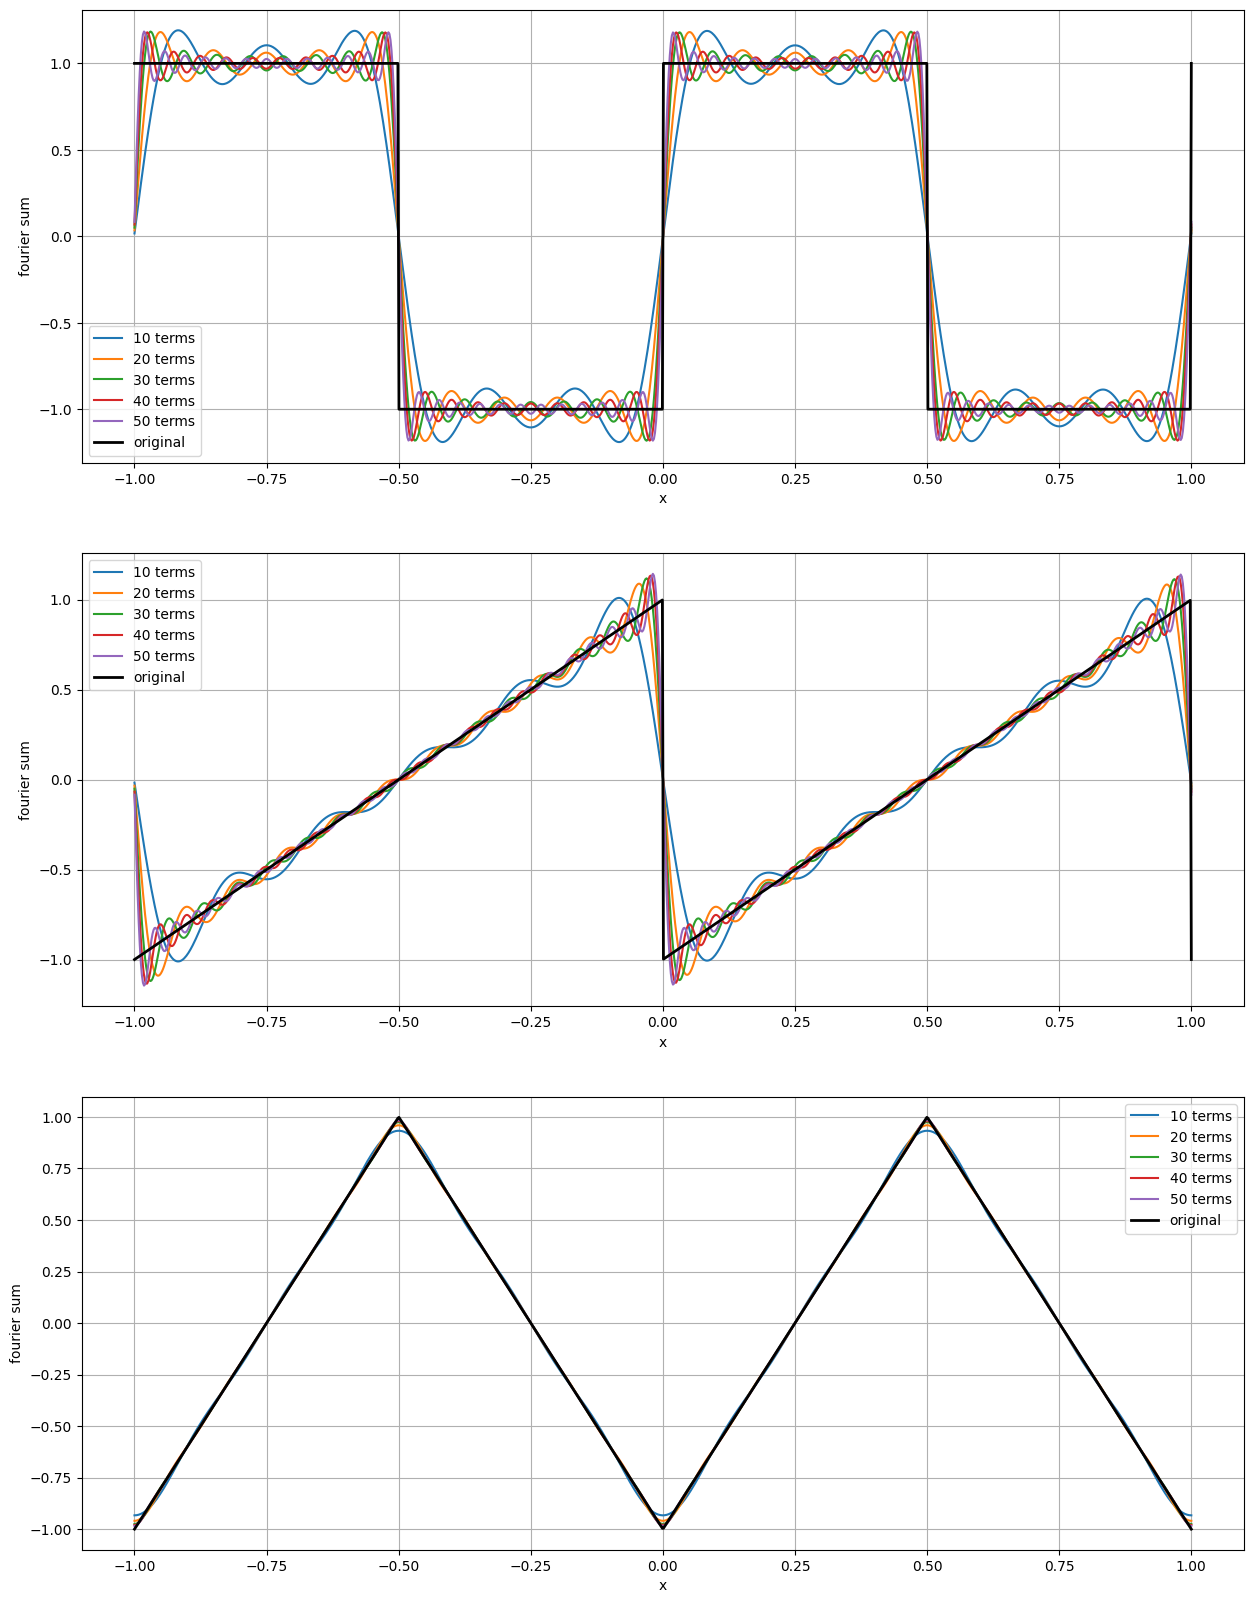

In [10]:
import numpy as np
from scipy import integrate, signal
import matplotlib.pyplot as plt

l = 1
x = np.linspace(-l, l, 1000)
plt.figure(figsize=(15, 20))

fsquare = signal.square(2 * x * np.pi)
fsaw = signal.sawtooth(2 * x * np.pi, 1)
ftri = signal.sawtooth(2 * x * np.pi, .5)

# NOTE: scipy.integrate.simps was removed in newer SciPy versions;
# use scipy.integrate.simpson instead (same trapezoid/Simpson-rule integration).
a0 = lambda f: integrate.simpson(f, x=x) / l
an = lambda f, n: integrate.simpson(f * np.cos(n * np.pi * x / l), x=x) / l
bn = lambda f, n: integrate.simpson(f * np.sin(n * np.pi * x / l), x=x) / l

i = 1
for f in [fsquare, fsaw, ftri]:
    z = int('31' + str(i))
    plt.subplot(z)
    for nupper in range(10, 60, 10):  # for different number of terms
        a0s = a0(f) / 2
        total = a0s
        for n in range(1, nupper + 1):
            ans = an(f, n) * np.cos(n * np.pi * x / l)
            bns = bn(f, n) * np.sin(n * np.pi * x / l)
            total += ans + bns
        # NOTE: this plot call was originally indented inside the inner "for n"
        # loop, so it fired on every n instead of once per nupper -- that drew
        # 10+20+30+40+50 = 150 overlapping lines per subplot, all with duplicate
        # labels. Moving it here (after the inner loop finishes) draws exactly
        # one curve per nupper value, as intended.
        plt.plot(x, total, label=str(nupper) + ' terms')
    plt.xlabel('x')
    plt.ylabel('fourier sum')
    plt.plot(x, f, 'k', lw=2, label='original')
    i += 1
    plt.legend()
    plt.grid(True)

plt.show()

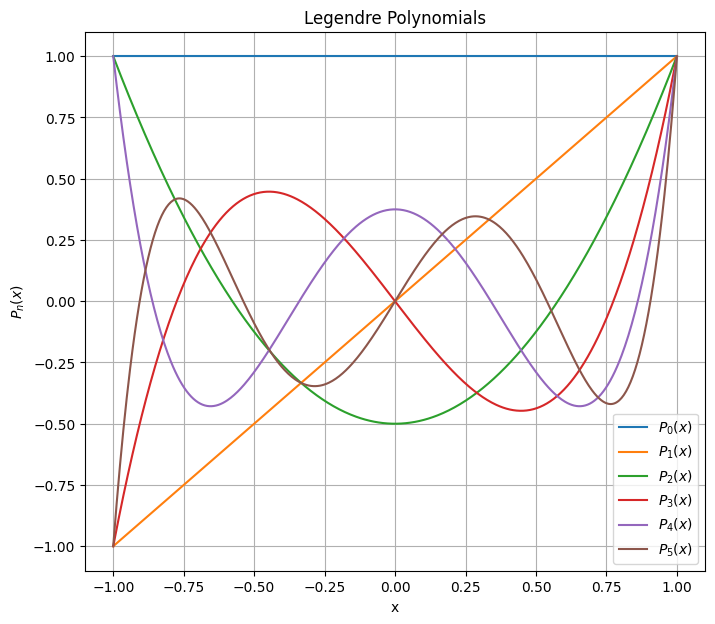

In [11]:
#To plot Legendre Polynomials
import numpy as np
from scipy.special import legendre as P
import matplotlib.pyplot as plt
x=np.linspace(-1,1,500)
N=5
plt.figure(figsize=(8,7))
for n in range(N+1):
 plt.plot(x,P(n)(x),label=r"$P_%d(x)$"%(n))
plt.grid()
plt.xlabel('x')
plt.ylabel('$P_n(x)$')
plt.title('Legendre Polynomials')
plt.legend(loc='best')
plt.show()


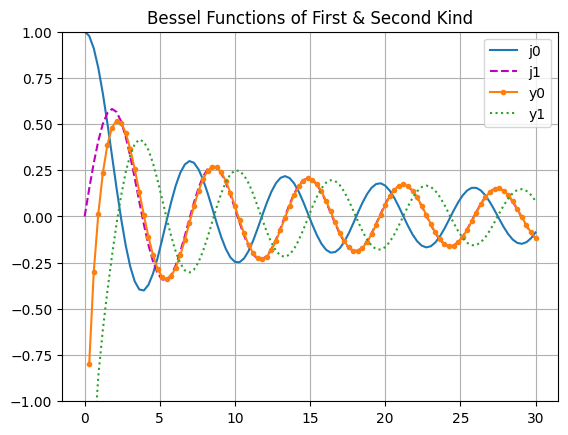

In [12]:
import numpy as np
import scipy.special as s
import matplotlib.pyplot as plt


x=np.linspace(0,30,100)


j0=s.jn(0,x)
j1=s.jn(1,x)
y0=s.yn(0,x)
y1=s.yn(1,x)


plt.plot(x,j0,'-',label='j0')
plt.plot(x,j1,'--',label='j1',c='m')
plt.plot(x,y0,'.-',label='y0')
plt.plot(x,y1,':',label='y1')
plt.grid()
plt.title("Bessel Functions of First & Second Kind")
plt.legend()
plt.ylim(-1,1)
plt.show()
